In [129]:
import pandas as pd
import io
import requests
import os
import matplotlib.pyplot as plt

In [19]:
with open("pracownicy_cp1250.csv", encoding="utf-8", errors="replace") as f:
    content = f.read()

df2 = pd.read_csv(io.StringIO(content))
print(df2.head())


     imie   nazwisko    miasto   stanowisko
0    Anna  Kowalczyk      ��d�     in�ynier
1  Bartek      �urek    Krak�w     analityk
2  Celina     �l�zak    Gda�sk    kierownik
3  Damian     W�jcik    Pozna�  programista
4     Ewa      ��cka  Warszawa     ksi�gowa


In [20]:
with open("pracownicy_utf8.csv", encoding="cp1250", errors="replace") as f:
    content = f.read()

df2 = pd.read_csv(io.StringIO(content))
print(df2.head())


     imie   nazwisko    miasto   stanowisko
0    Anna  Kowalczyk   Ĺ�ĂłdĹş    inĹĽynier
1  Bartek     Ĺ»urek   KrakĂłw     analityk
2  Celina   ĹšlÄ…zak   GdaĹ„sk    kierownik
3  Damian    WĂłjcik   PoznaĹ„  programista
4     Ewa    Ĺ�Ä™cka  Warszawa    ksiÄ™gowa


In [35]:
df = pd.read_csv("pracownicy_cp1250.csv", encoding="cp1250")
df.to_csv("pracownicy_utf8_new.csv", encoding="utf-8", index=False)
df.head()

,imie,nazwisko,miasto,stanowisko
0,Anna,Kowalczyk,Łódź,inżynier
1,Bartek,Żurek,Kraków,analityk
2,Celina,Ślązak,Gdańsk,kierownik
3,Damian,Wójcik,Poznań,programista
4,Ewa,Łęcka,Warszawa,księgowa


In [ ]:
//cwiczenie 2: Brudaski CSV

In [40]:
pd.read_csv("klienci.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb3 in position 98: invalid start byte

In [74]:
nig = pd.read_csv("klienci.csv", encoding="cp1250", sep=";", decimal=",", na_values=["brak", "-", "?"])
nig["data_rejestracji"] = pd.to_datetime(nig["data_rejestracji"], format="%d.%m.%Y")
nig[nig['miasto'] == 'Łódź']
srednidochod=nig[nig['miasto'] == 'Łódź']['dochod'].mean()
ilosc= len(nig[nig['miasto'] == 'Łódź'])
print(f"sredni dochód dla Lodzi to {srednidochod} ilosc klientów to {ilosc}")

sredni dochód dla Lodzi to 3783.5833333333335 ilosc klientów to 3


In [77]:
nig.to_parquet("klienci.parquet")
print(os.path.getsize("klienci.csv"))
print(os.path.getsize("klienci.parquet"))

924
5639


In [75]:
nig.dtypes

,0
id,int64
kod_pocztowy,object
data_rejestracji,datetime64[ns]
miasto,object
adres,object
dochod,float64
wiek,float64


Cwiczenie 3 //NBAPPE

                  EUR     USD     GBP
effectiveDate                        
2026-04-23     4.2501  3.6321  4.9046
2026-04-24     4.2428  3.6294  4.8911
2026-04-27     4.2445  3.6130  4.8970
2026-04-28     4.2470  3.6293  4.9016
2026-04-29     4.2537  3.6356  4.9076


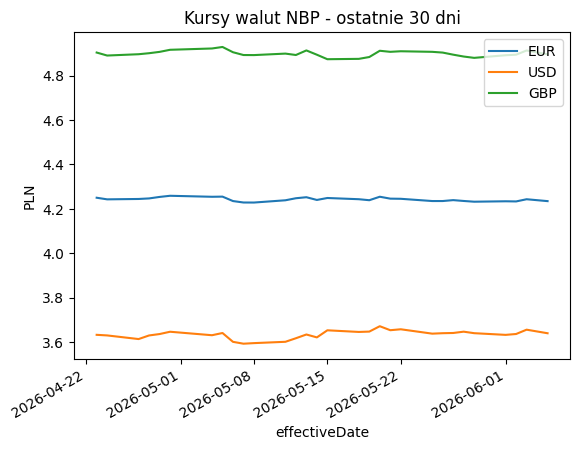

In [98]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

def get_currency(code):
    url = f"https://api.nbp.pl/api/exchangerates/rates/A/{code}/last/30/"
    data = requests.get(url).json()
    df = pd.DataFrame(data['rates'])
    df['effectiveDate'] = pd.to_datetime(df['effectiveDate'])
    df = df.set_index('effectiveDate')['mid']
    df.name = code
    return df

eur = get_currency('EUR')
usd = get_currency('USD')
gbp = get_currency('GBP')

df_all = pd.concat([eur, usd, gbp], axis=1)
print(df_all.head())

df_all.plot(title="Kursy walut NBP - ostatnie 30 dni")
plt.ylabel("PLN")
plt.show()

df_all.to_parquet("kursy.parquet")

In [127]:
urleur = 'https://api.nbp.pl/api/exchangerates/rates/A/EUR/2024-01-01/2024-12-31/'
data = requests.get(urleur).json()
data = pd.DataFrame(data['rates'])
data["effectiveDate"] = pd.to_datetime(data["effectiveDate"], format="%Y-%m-%d")
data.sort_values(['mid'], ascending=False).head(1)




,no,effectiveDate,mid
12,013/A/NBP/2024,2024-01-18,4.4016


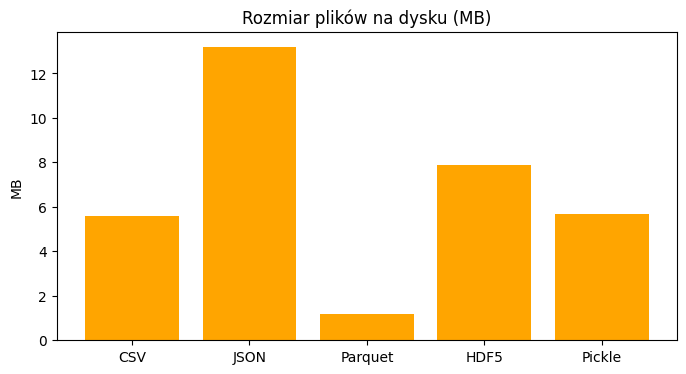

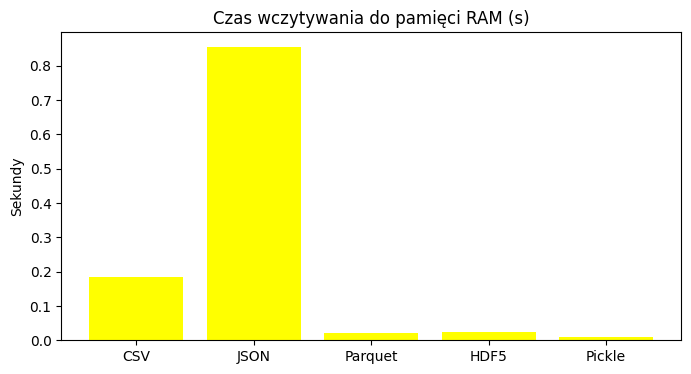

Czas wczytania Parquet: 0.02165 s
Czas wczytania 2 kolumn Parquet:  0.01326 s
Do długoterminowego przechowywaniaтPARQUET.
Do szybkich analiz PICKLE lub PARQUET.


In [132]:
df = pd.read_csv('pomiary.csv')

df.to_json('pomiary.json')
df.to_parquet('pomiary.parquet')
df.to_hdf('pomiary.h5', key='data', mode='w')
df.to_pickle('pomiary.pkl')

formaty = ['CSV', 'JSON', 'Parquet', 'HDF5', 'Pickle']
pliki = ['pomiary.csv', 'pomiary.json', 'pomiary.parquet', 'pomiary.h5', 'pomiary.pkl']

rozmiary = [os.path.getsize(plik) / (1024 * 1024) for plik in pliki]

plt.figure(figsize=(8, 4))
plt.bar(formaty, rozmiary, color='orange')
plt.title('Rozmiar plików na dysku (MB)')
plt.ylabel('MB')
plt.show()

czasy = []

t0 = time.perf_counter(); pd.read_csv('pomiary.csv'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_json('pomiary.json'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_parquet('pomiary.parquet'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_hdf('pomiary.h5'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_pickle('pomiary.pkl'); czasy.append(time.perf_counter() - t0)

plt.figure(figsize=(8, 4))
plt.bar(formaty, czasy, color='yellow')
plt.title('Czas wczytywania do pamięci RAM (s)')
plt.ylabel('Sekundy')
plt.show()
czas_parquet_all = czasy[2]
t0 = time.perf_counter()
pd.read_parquet('pomiary.parquet', columns=['date', 'pm25'])
czas_parquet_2 = time.perf_counter() - t0
print(f"Czas wczytania Parquet: {czas_parquet_all:.5f} s")
print(f"Czas wczytania 2 kolumn Parquet:  {czas_parquet_2:.5f} s")
print("Do długoterminowego przechowywaniaтPARQUET.")
print("Do szybkich analiz PICKLE lub PARQUET.")

In [134]:
import sqlite3

conn = sqlite3.connect("sklep.db")
tabele = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Dostępne tabele:", tabele['name'].tolist(), "\n")

df_klienci = pd.read_sql("SELECT * FROM klienci", conn)
df_produkty = pd.read_sql("SELECT * FROM produkty", conn)
df_zamowienia = pd.read_sql("SELECT * FROM zamowienia", conn)

print(f"Rozmiary tabel - Klienci: {df_klienci.shape}, Produkty: {df_produkty.shape}, Zamówienia: {df_zamowienia.shape}\n")
print("Typy kolumn (klienci):\n", df_klienci.dtypes, "\n")

sql_top10 = """
SELECT k.imie, k.nazwisko, COUNT(z.id) as liczba_zamowien
FROM klienci k
JOIN zamowienia z ON k.id = z.klient_id
GROUP BY k.id
ORDER BY liczba_zamowien DESC
LIMIT 10
"""
print("Top 10 klientów (SQL):")
print(pd.read_sql(sql_top10, conn), "\n")

paczki = pd.read_sql("SELECT * FROM zamowienia", conn, chunksize=100)
pierwsza_paczka = next(paczki)
print(f"Wczytano testowo pierwszą porcję (chunk). Rozmiar: {len(pierwsza_paczka)} rekordów.\n")

sql_sprzedaz = """
SELECT p.kategoria, SUM(p.cena * z.ilosc) as wartosc_sprzedazy
FROM produkty p
JOIN zamowienia z ON p.id = z.produkt_id
GROUP BY p.kategoria
"""
print("Sprzedaż per kategoria (SQL):")
print(pd.read_sql(sql_sprzedaz, conn), "\n")

merged = df_zamowienia.merge(df_produkty, left_on='produkt_id', right_on='id')
merged['wartosc_sprzedazy'] = merged['ilosc'] * merged['cena']
wynik_pandas = merged.groupby('kategoria')['wartosc_sprzedazy'].sum().reset_index()

print("Sprzedaż per kategoria (Pandas):")
print(wynik_pandas, "\n")

print("SQl krótszy, bardziej naturalny zapis")
print("Pandas wymaga więcej kroków, w przypadku duzych tabel operacja merge może zająć dużo pamięci.")

conn.close()


Dostępne tabele: ['klienci', 'produkty', 'zamowienia'] 

Rozmiary tabel - Klienci: (200, 6), Produkty: (15, 4), Zamówienia: (1000, 5)

Typy kolumn (klienci):
 id                   int64
imie                object
nazwisko            object
miasto              object
wiek                 int64
data_rejestracji    object
dtype: object 

Top 10 klientów (SQL):
      imie    nazwisko  liczba_zamowien
0    Piotr      Wójcik               10
1  Grażyna     Woźniak               10
2   Michał     Woźniak               10
3     Adam    Kamiński                9
4   Tomasz  Wiśniewski                9
5   Damian    Kowalski                9
6    Maria     Woźniak                9
7   Michał   Kozłowski                9
8    Filip   Kowalczyk                9
9   Bartek     Woźniak                9 

Wczytano testowo pierwszą porcję (chunk). Rozmiar: 100 rekordów.

Sprzedaż per kategoria (SQL):
     kategoria  wartosc_sprzedazy
0    Akcesoria            60495.0
1        Biuro            11625.0
